# OULAD learner behaviour and early risk

This project uses the Open University Learning Analytics Dataset (OULAD), which links learner and course information with assessments, final results, and daily virtual-learning-environment (VLE) activity.

**RQ1 — Behavioural profiles:** What early VLE behaviour profiles appear, and how do their activity and final outcomes differ? **H1:** Low-activity learners will have a higher withdrawal rate than steady-activity learners.

**RQ2 — Early risk prediction:** How well can information available by week 8 identify learners who eventually Fail or Withdraw? **H2:** Week-eight engagement, assessment, and learner/course features will predict this outcome better than chance (ROC-AUC > 0.50).


## 1. Load the dataset

Load the seven OULAD tables from the project data folder and inspect the learner-course outcome counts.

In [778]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

SEED = 42
EARLY_WEEKS = 8
EARLY_DAYS = EARLY_WEEKS * 7
FINAL_RESULT_ORDER = ["Withdrawn", "Fail", "Pass", "Distinction"]

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw" / "oulad").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
OULAD_DIR = PROJECT_ROOT / "data" / "raw" / "oulad"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "oulad_figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, filename):
    """Save a finished notebook figure as a print-ready PDF."""
    path = OUTPUTS_DIR / f"{filename}.pdf"
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print(f"Saved figure: {path.relative_to(PROJECT_ROOT)}")

sns.set_theme(style="whitegrid", context="notebook")

vle_dtypes = {
    "code_module": "category", "code_presentation": "category",
    "id_student": "int32", "id_site": "int32", "date": "int16",
    "sum_click": "int32",
}
table_names = [
    "assessments", "courses", "studentAssessment", "studentInfo",
    "studentRegistration", "studentVle", "vle",
]
tables = {}
for name in table_names:
    csv_path = OULAD_DIR / f"{name}.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing OULAD file: {csv_path}")
    tables[name] = pd.read_csv(csv_path, dtype=vle_dtypes if name == "studentVle" else None)

print(f"Loaded {len(tables)} OULAD tables from {OULAD_DIR}")
display(pd.DataFrame([
    {"table": name, "rows": len(frame), "columns": len(frame.columns)}
    for name, frame in tables.items()
])) 

Loaded 7 OULAD tables from C:\Users\mradu\Documents\Codex\2026-10-02\hi\data\raw\oulad


,table,rows,columns
0,assessments,206,6
1,courses,22,3
2,studentAssessment,173912,5
3,studentInfo,32593,12
4,studentRegistration,32593,5
5,studentVle,10655280,6
6,vle,6364,6


In [779]:
print("Final outcomes before integration:")
display(tables["studentInfo"]["final_result"].value_counts().rename_axis("Final result").to_frame("Learner-course records"))
print(f"Total learner-course records: {len(tables['studentInfo']):,}")

Final outcomes before integration:


,Learner-course records
Final result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


Total learner-course records: 32,593


## 2. Data preprocessing

### Tables and integration

| CSV | What it contains | How it is used |
|---|---|---|
| `studentInfo` | Learner, course presentation, and final result | One row per learner-course presentation and the outcome label |
| `studentRegistration` | Registration and unregistration dates | Registration context; unregistration is excluded from prediction |
| `courses` | Course presentation lengths | Course context |
| `assessments` | Assessment type and due date | Identify assessments due during the first eight weeks |
| `studentAssessment` | Submission dates, scores, and banked-score flag | Build early submission and score features |
| `studentVle` | Learner resource clicks by day | Build weekly engagement features |
| `vle` | Resource details and planned study weeks | Add resource context; observed click dates define activity timing |

OULAD stores these details in separate linked files. We use `studentInfo` as the learner-course table, join registration and course details with their matching keys, summarize submissions and clicks separately, and then add those summaries to the learner-course records.

In [781]:
print("First five rows of each source table:")
for name, frame in tables.items():
    print(f"\n{name}.csv — {len(frame):,} rows, {len(frame.columns)} columns")
    display(frame.head())

First five rows of each source table:

assessments.csv — 206 rows, 6 columns


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0



courses.csv — 22 rows, 3 columns


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240



studentAssessment.csv — 173,912 rows, 5 columns


...

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN



studentVle.csv — 10,655,280 rows, 6 columns


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1



vle.csv — 6,364 rows, 6 columns


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [782]:
missing_rows = [
    {"table": name, "column": column, "missing": int(frame[column].isna().sum()),
     "missing_percent": round(100 * frame[column].isna().mean(), 2)}
    for name, frame in tables.items()
    for column in frame.columns if frame[column].isna().any()
]
missingness = pd.DataFrame(missing_rows, columns=["table", "column", "missing", "missing_percent"])
print("Columns with missing values in the raw files:")
if missingness.empty:
    print("None")
else:
    display(missingness.sort_values(["table", "column"]).reset_index(drop=True))
score_rows_raw = tables["studentAssessment"]
score_missing = score_rows_raw["score"].isna()
print(f"Missing scores: {score_missing.sum():,} of {len(score_rows_raw):,} submission records.")
print(f"Missing-score rows that still have a submission date: {score_rows_raw.loc[score_missing, 'date_submitted'].notna().sum():,}.")
print("These are unscored recorded submissions, not non-submissions or scores of zero.")


Columns with missing values in the raw files:


,table,column,missing,missing_percent
0,assessments,date,11,5.34
1,studentAssessment,score,173,0.10
2,studentInfo,imd_band,1111,3.41
3,studentRegistration,date_registration,45,0.14
4,studentRegistration,date_unregistration,22521,69.10
5,vle,week_from,5243,82.39
6,vle,week_to,5243,82.39


Missing scores: 173 of 173,912 submission records.
Missing-score rows that still have a submission date: 173.
These are unscored recorded submissions, not non-submissions or scores of zero.


### Data cleaning

We trim accidental spaces from text fields and remove fully identical rows from non-`studentVle` tables. Every `studentVle` row is retained because its recorded click count contributes to activity totals; joins check the required key relationships.

In [784]:
# Normalize incidental whitespace, remove exact duplicates from non-event tables,
# and audit (but never drop) studentVle rows and partial-key collisions.
key_specs = {
    "studentInfo": ["code_module", "code_presentation", "id_student"],
    "studentRegistration": ["code_module", "code_presentation", "id_student"],
    "courses": ["code_module", "code_presentation"],
    "assessments": ["id_assessment"],
    "studentAssessment": ["id_assessment", "id_student"],
    "vle": ["code_module", "code_presentation", "id_site"],
    "studentVle": ["code_module", "code_presentation", "id_student", "id_site", "date"],
}
cleaning_rows = []
for table_name, frame in list(tables.items()):
    before = len(frame)
    text_columns = [
        column for column in frame.columns
        if pd.api.types.is_object_dtype(frame[column].dtype)
        or pd.api.types.is_string_dtype(frame[column].dtype)
    ]
    for column in text_columns:
        frame[column] = frame[column].str.strip()

    exact_duplicates = int(frame.duplicated().sum())
    if table_name == "studentVle":
        # Preserve every recorded event row, even if rows appear identical.
        tables[table_name] = frame
        removed = 0
    else:
        cleaned = frame.drop_duplicates().copy()
        removed = before - len(cleaned)
        tables[table_name] = cleaned
        frame = cleaned

    key = key_specs.get(table_name, [])
    duplicate_key_rows = (
        int(frame.duplicated(subset=key, keep="first").sum())
        if key and all(column in frame.columns for column in key)
        else 0
    )
    cleaning_rows.append({
        "Table": table_name,
        "Rows before": before,
        "Exact duplicate rows found": exact_duplicates,
        "Rows removed": removed,
        "Rows after": len(frame),
        "Extra rows on audited key": duplicate_key_rows,
    })

cleaning_audit = pd.DataFrame(cleaning_rows)
display(cleaning_audit)
print("studentVle rows removed: 0. Partial-key collisions are reported, not silently dropped.")


,Table,Rows before,Exact duplicate rows found,Rows removed,Rows after,Extra rows on audited key
0,assessments,206,0,0,206,0
1,courses,22,0,0,22,0
2,studentAssessment,173912,0,0,173912,0
3,studentInfo,32593,0,0,32593,0
4,studentRegistration,32593,0,0,32593,0
5,studentVle,10655280,787170,0,10655280,2195960
6,vle,6364,0,0,6364,0


studentVle rows removed: 0. Partial-key collisions are reported, not silently dropped.


### Missing values

| Missing field | Treatment |
|---|---|
| `vle.week_from`, `vle.week_to` | Keep blank; observed click dates provide the timeline. |
| `studentRegistration.date_unregistration` | Keep blank and exclude from predictors because it can reveal withdrawal. |
| `assessments.date` | Exclude the 11 undated final exams from early-deadline features; retain learners. |
| `studentAssessment.score` | Keep the submission for counts/timing; use only recorded scores in score summaries. Do not invent a mark. |
| `studentInfo.imd_band`, `studentRegistration.date_registration` | Retain learners; use training-only model imputation if these predictors are missing. |

An absent learner-week in the activity panel means zero recorded clicks. Raw scores are not globally imputed. The model’s missing predictor values are imputed after the learner-level split, using training data only; this prevents test data from influencing the imputation values.

### Integrating the learner-course table

We add registration and course length to the learner-course base using shared keys. Event tables are summarized separately, then their features are joined after creation.

In [787]:
learner_key = ["code_module", "code_presentation", "id_student"]
course_key = ["code_module", "code_presentation"]

student_course = tables["studentInfo"].merge(
    tables["studentRegistration"], on=learner_key, how="left",
    validate="one_to_one", indicator="_registration_match"
)
unmatched_registration = int(student_course["_registration_match"].eq("left_only").sum())
student_course = student_course.drop(columns="_registration_match").merge(
    tables["courses"], on=course_key, how="left",
    validate="many_to_one", indicator="_course_match"
)
unmatched_course = int(student_course["_course_match"].eq("left_only").sum())
student_course = student_course.drop(columns="_course_match")
assert not student_course.duplicated(learner_key).any(), "Learner-course join produced duplicate keys."
assert unmatched_registration == 0 and unmatched_course == 0, "Some base learner-course rows did not match lookup tables."
# Registration timing is known at course start; missing dates remain missing for pipeline imputation.
student_course["registration_lead_days"] = -student_course["date_registration"]
student_course["fail_or_withdrawn"] = student_course["final_result"].isin(["Fail", "Withdrawn"])
student_course["withdrawn"] = student_course["final_result"].eq("Withdrawn")

print(f"Base learner-course rows retained: {len(student_course):,}")
print(f"Unmatched registration rows: {unmatched_registration}; unmatched course-presentation rows: {unmatched_course}")
print(f"Unique learner-course keys: {student_course[learner_key].drop_duplicates().shape[0]:,}")
display(student_course["final_result"].value_counts(dropna=False).rename_axis("final_result").to_frame("learners"))

Base learner-course rows retained: 32,593
Unmatched registration rows: 0; unmatched course-presentation rows: 0
Unique learner-course keys: 32,593


,learners
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


## 3. Research question 1 — Behavioural profiles

**RQ1:** What three early engagement profiles appear in VLE activity, and how do their activity patterns and final outcomes differ?

**H1:** Learners assigned to **Low activity** will have a higher withdrawal rate than learners assigned to **Steady activity**. We also describe a **Deadline focused** profile by its timing of clicks around known early assessment deadlines.

**Features (first eight course weeks):** total clicks, active-week share, week-to-week click variability, and deadline-click share. A zero-click learner receives a deadline-click share of 0 as a computational placeholder; `early_clicks` distinguishes this case. Plots of deadline share include clickers only.

**Method:** Log-transform skewed click measures, standardize the four features, and use the inertia elbow to select K-Means K. Fit clusters among learners with clicks, then assign zero-click learners to Low activity. Compare the profiles’ feature distributions, temporal activity, and outcomes.

In [789]:
vle_early = tables["studentVle"].loc[
    tables["studentVle"]["date"].between(0, EARLY_DAYS - 1),
    learner_key + ["date", "sum_click"],
].copy()
vle_early["week"] = (vle_early["date"] // 7).astype("int8")
weekly_observed = (
    vle_early.groupby(learner_key + ["week"], as_index=False, observed=True)
    .agg(weekly_clicks=("sum_click", "sum"))
)

base_keys = student_course[learner_key].reset_index(drop=True)
early_panel = base_keys.loc[np.repeat(np.arange(len(base_keys)), EARLY_WEEKS)].reset_index(drop=True)
early_panel["week"] = np.tile(np.arange(EARLY_WEEKS, dtype="int8"), len(base_keys))
early_panel = early_panel.merge(
    weekly_observed, on=learner_key + ["week"], how="left", validate="one_to_one"
)
early_panel["weekly_clicks"] = early_panel["weekly_clicks"].fillna(0).astype("int32")

weekly_matrix = (
    early_panel.pivot(index=learner_key, columns="week", values="weekly_clicks")
    .reindex(columns=range(EARLY_WEEKS), fill_value=0)
    .fillna(0)
)
click_matrix = weekly_matrix.to_numpy(dtype=float)
click_mean = click_matrix.mean(axis=1)
clicks_first4 = click_matrix[:, :4].sum(axis=1)
clicks_last4 = click_matrix[:, 4:].sum(axis=1)

def longest_zero_click_run(row):
    longest = current = 0
    for value in row:
        current = current + 1 if value == 0 else 0
        longest = max(longest, current)
    return longest

inactive_gap = np.fromiter(
    (longest_zero_click_run(row) for row in click_matrix), dtype=np.int8, count=len(click_matrix)
)
weekly_cv = np.divide(
    click_matrix.std(axis=1), click_mean,
    out=np.zeros_like(click_mean), where=click_mean > 0,
)
early_activity = pd.DataFrame({
    "early_clicks": click_matrix.sum(axis=1).astype("int64"),
    "active_weeks": (click_matrix > 0).sum(axis=1),
    "active_week_ratio": (click_matrix > 0).mean(axis=1),
    "weekly_click_cv": weekly_cv,
    "early_clicks_first4": clicks_first4.astype("int64"),
    "early_clicks_last4": clicks_last4.astype("int64"),
    "early_click_trend": np.log1p(clicks_last4) - np.log1p(clicks_first4),
    "longest_inactive_gap_weeks": inactive_gap,
}, index=weekly_matrix.index).reset_index()
print(f"Complete early panel: {len(early_panel):,} learner-week rows")
display(early_activity.head(3))

Complete early panel: 260,744 learner-week rows


,code_module,code_presentation,id_student,early_clicks,active_weeks,active_week_ratio,weekly_click_cv,early_clicks_first4,early_clicks_last4,early_click_trend,longest_inactive_gap_weeks
0,AAA,2013J,11391,431,7,0.875,1.054679,303,128,-0.857215,1
1,AAA,2013J,28400,454,7,0.875,0.890467,335,119,-1.029619,1
2,AAA,2013J,30268,179,2,0.250,1.775649,179,0,-5.192957,6


In [790]:
# Click share during the seven in-course days before known deadlines in weeks 0-7.
deadline_parts = []
assessment_table = tables["assessments"]
for (module, presentation), event_group in vle_early.groupby(course_key, observed=True):
    due_days = assessment_table.loc[
        (assessment_table["code_module"] == module)
        & (assessment_table["code_presentation"] == presentation), "date"
    ].dropna().to_numpy()
    due_days = np.unique(due_days[(due_days >= 0) & (due_days < EARLY_DAYS)].astype(int))
    if len(due_days) == 0:
        continue
    event_days = event_group["date"].to_numpy()
    in_deadline_window = np.zeros(len(event_group), dtype=bool)
    for due_day in due_days:
        in_deadline_window |= (event_days >= max(0, due_day - 7)) & (event_days < due_day)
    near_deadline = (
        event_group.loc[in_deadline_window]
        .groupby("id_student", as_index=False)["sum_click"].sum()
        .rename(columns={"sum_click": "deadline_clicks"})
    )
    near_deadline["code_module"] = module
    near_deadline["code_presentation"] = presentation
    deadline_parts.append(near_deadline)

deadline_features = (
    pd.concat(deadline_parts, ignore_index=True)
    if deadline_parts else pd.DataFrame(columns=learner_key + ["deadline_clicks"])
)
print(f"Learner-course records with early deadline windows: {deadline_features[learner_key].drop_duplicates().shape[0]:,}")

Learner-course records with early deadline windows: 24,123


In [791]:
early_features = early_activity.merge(
    deadline_features, on=learner_key, how="left", validate="one_to_one"
)
early_features["deadline_clicks"] = early_features["deadline_clicks"].fillna(0)
early_features["deadline_click_share"] = np.divide(
    early_features["deadline_clicks"], early_features["early_clicks"],
    out=np.zeros(len(early_features), dtype=float), where=early_features["early_clicks"].to_numpy() > 0,
)
analysis = student_course.merge(early_features, on=learner_key, how="left", validate="one_to_one")
analysis["early_clicks_per_studied_credit"] = (
    analysis["early_clicks"] / analysis["studied_credits"].replace(0, np.nan)
)
analysis["risk_group"] = np.where(
    analysis["fail_or_withdrawn"], "Fail / withdrawn", "Pass / distinction"
)
print("Analysis table:", analysis.shape)
print("Early engagement feature columns:", [
    "early_clicks", "active_week_ratio", "weekly_click_cv", "deadline_click_share",
])



Analysis table: (32593, 30)
Early engagement feature columns: ['early_clicks', 'active_week_ratio', 'weekly_click_cv', 'deadline_click_share']


Saved figure: outputs\oulad_figures\01_early_behaviour_by_outcome.pdf


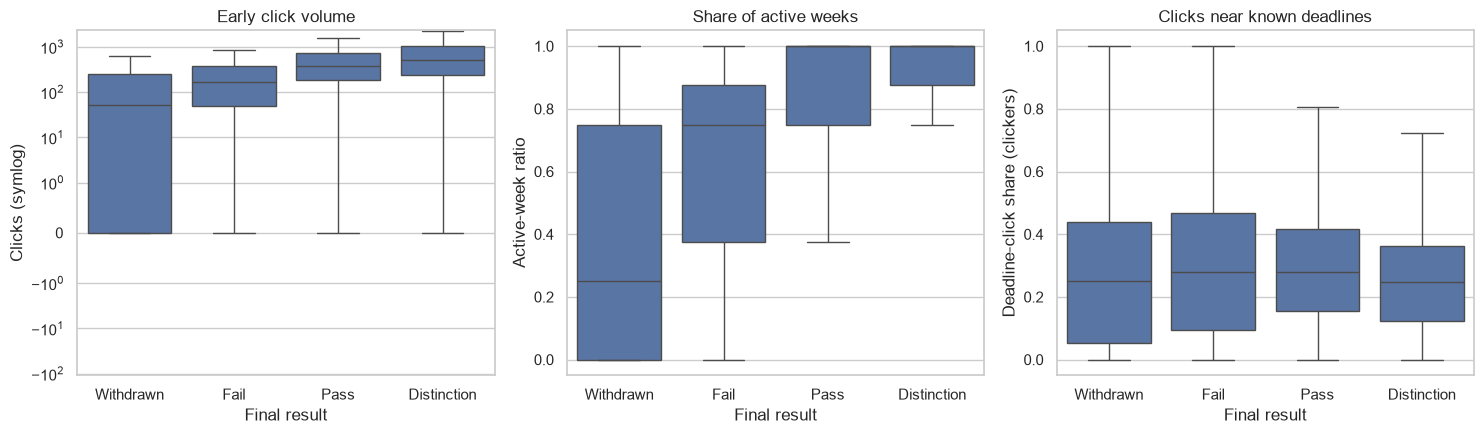

In [792]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=analysis, x="final_result", order=FINAL_RESULT_ORDER, y="early_clicks", showfliers=False, ax=axes[0])
axes[0].set_yscale("symlog", linthresh=1)
axes[0].set(title="Early click volume", xlabel="Final result", ylabel="Clicks (symlog)")
sns.boxplot(data=analysis, x="final_result", order=FINAL_RESULT_ORDER, y="active_week_ratio", showfliers=False, ax=axes[1])
axes[1].set(title="Share of active weeks", xlabel="Final result", ylabel="Active-week ratio")
clickers = analysis.loc[analysis["early_clicks"].gt(0)]
sns.boxplot(data=clickers, x="final_result", order=FINAL_RESULT_ORDER, y="deadline_click_share", showfliers=False, ax=axes[2])
axes[2].set(title="Clicks near known deadlines", xlabel="Final result", ylabel="Deadline-click share (clickers)")
for ax in axes: ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
save_figure(fig, "01_early_behaviour_by_outcome")
plt.show()

### Choose the number of profiles

The inertia curve bends near **K = 3**, so we use three clusters among learners with clicks. Learners with no recorded clicks are assigned to **Low activity**.

Saved figure: outputs\oulad_figures\02_active_learner_elbow.pdf


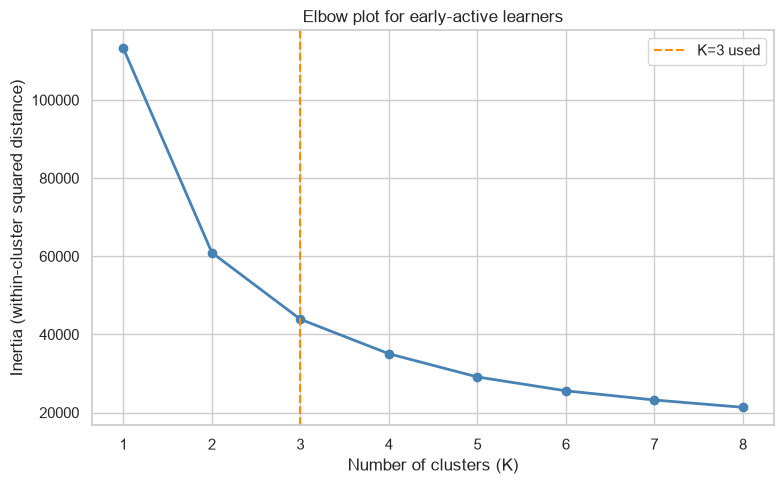

Final profiles: K=3 active clusters; 4,290 zero-click learners are included in Low activity; three profile classes total.
Interpretation: Low activity has the smallest median click volume; Deadline focused has the largest deadline-click share among the other profiles; Steady activity is the remaining active pattern.


,profile_name,learners,median_early_clicks,median_active_weeks,median_weekly_cv,median_deadline_click_share
0,Low activity,9632,6.0,1.0,1.241216,0.000000
1,Deadline focused,5513,145.0,5.0,1.382777,0.605769
2,Steady activity,17448,490.0,8.0,0.731933,0.263780


,K,inertia
0,1,113212.0
1,2,60925.6
2,3,43866.9
3,4,35039.7
4,5,29104.9
5,6,25562.0
6,7,23204.3
7,8,21333.3


In [794]:
cluster_columns = ["log_early_clicks", "active_week_ratio", "log_weekly_cv", "deadline_click_share"]
analysis["log_early_clicks"] = np.log1p(analysis["early_clicks"])
analysis["log_weekly_cv"] = np.log1p(analysis["weekly_click_cv"].clip(upper=10))
no_click = analysis["early_clicks"].eq(0)
active = ~no_click

# Fit K-Means to active learners; the zero-click records will join the lowest-activity group.
scaler = StandardScaler()
active_cluster_matrix = scaler.fit_transform(analysis.loc[active, cluster_columns])

# One inertia/elbow plot. The curve supports the K=3 choice for active learners.
k_rows = []
for k in range(1, 9):
    candidate = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    candidate.fit(active_cluster_matrix)
    k_rows.append({"K": k, "inertia": candidate.inertia_})
k_sweep = pd.DataFrame(k_rows)
selected_k = 3
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_sweep["K"], k_sweep["inertia"], marker="o", color="steelblue", linewidth=2)
ax.axvline(selected_k, color="darkorange", linestyle="--", label="K=3 used")
ax.set(title="Elbow plot for early-active learners",
       xlabel="Number of clusters (K)", ylabel="Inertia (within-cluster squared distance)")
ax.legend()
plt.tight_layout()
save_figure(fig, "02_active_learner_elbow")
plt.show()

kmeans = KMeans(n_clusters=selected_k, random_state=SEED, n_init=20)
active_labels = kmeans.fit_predict(active_cluster_matrix) + 1
analysis["behavior_profile"] = 0
analysis.loc[active, "behavior_profile"] = active_labels
active_summary = analysis.loc[active].groupby("behavior_profile").agg(
    median_early_clicks=("early_clicks", "median"),
    median_active_week_ratio=("active_week_ratio", "median"),
    median_weekly_cv=("weekly_click_cv", "median"),
    median_deadline_click_share=("deadline_click_share", "median"),
)
# Assign distinct, evidence-based names to the three active clusters.
low_profile = int(active_summary["median_early_clicks"].idxmin())
remaining_profiles = [p for p in active_summary.index if int(p) != low_profile]
deadline_profile = int(active_summary.loc[remaining_profiles, "median_deadline_click_share"].idxmax())
steady_profile = int(next(p for p in remaining_profiles if int(p) != deadline_profile))
# Zero-click learners are retained and joined to the least-active K-Means group.
analysis.loc[no_click, "behavior_profile"] = low_profile
profile_labels = {
    low_profile: "Low activity",
    deadline_profile: "Deadline focused",
    steady_profile: "Steady activity",
}
profile_order = [low_profile, deadline_profile, steady_profile]
profile_plot_order = [profile_labels[p] for p in profile_order]
analysis["profile_name"] = analysis["behavior_profile"].map(profile_labels)
profile_summary = (analysis.groupby("behavior_profile")
    .agg(learners=("id_student", "size"), median_early_clicks=("early_clicks", "median"),
         median_active_week_ratio=("active_week_ratio", "median"), median_weekly_cv=("weekly_click_cv", "median"))
    .reindex(profile_order).reset_index())
clicker_deadline_medians = (analysis.loc[analysis["early_clicks"].gt(0)]
    .groupby("behavior_profile")["deadline_click_share"].median())
profile_summary["median_deadline_click_share"] = profile_summary["behavior_profile"].map(clicker_deadline_medians)
profile_summary["profile_name"] = profile_summary["behavior_profile"].map(profile_labels)
profile_summary["median_active_weeks"] = (profile_summary["median_active_week_ratio"] * EARLY_WEEKS).round(1)
print(f"Final profiles: K={selected_k} active clusters; {int(no_click.sum()):,} zero-click learners are included in Low activity; three profile classes total.")
print("Interpretation: Low activity has the smallest median click volume; Deadline focused has the largest deadline-click share among the other profiles; Steady activity is the remaining active pattern.")
display(profile_summary[["profile_name", "learners", "median_early_clicks", "median_active_weeks", "median_weekly_cv", "median_deadline_click_share"]])
display(k_sweep.round(1))

### K-Means profile map

This PCA chart displays the fitted profiles and their centers in two dimensions. K-Means used all four standardized features.

Saved figure: outputs\oulad_figures\05_profile_pca_map.pdf


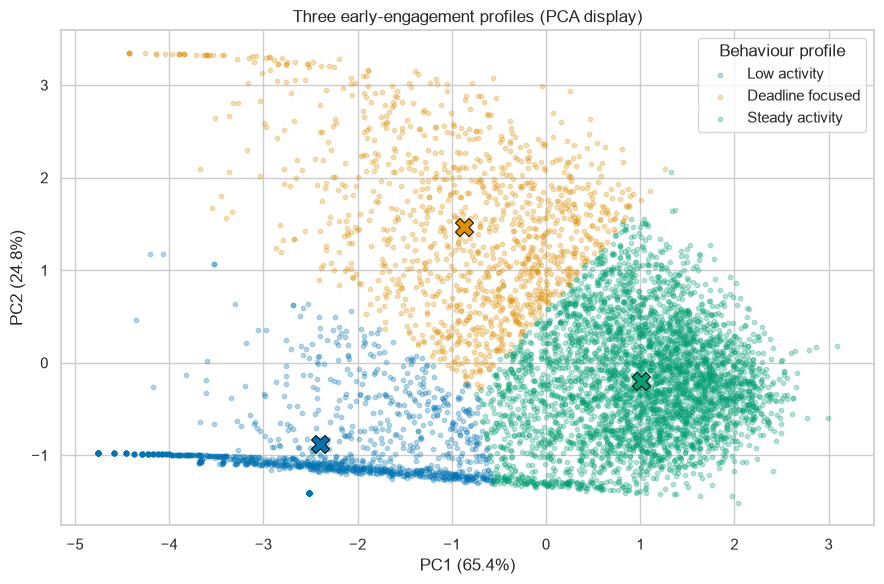

PCA is for display only; clustering used all four standardized behaviour features.


In [796]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
pca.fit(active_cluster_matrix)
all_coordinates = pca.transform(scaler.transform(analysis[cluster_columns]))
profile_points = pd.DataFrame({"PC1": all_coordinates[:, 0], "PC2": all_coordinates[:, 1],
                               "profile": analysis["behavior_profile"].to_numpy()})
plot_points = profile_points.sample(n=min(7000, len(profile_points)), random_state=SEED)
projected_centers = pca.transform(kmeans.cluster_centers_)
palette = sns.color_palette("colorblind", n_colors=3)
profile_colors = {p: palette[i] for i, p in enumerate(profile_order)}
fig, ax = plt.subplots(figsize=(9, 6))
for profile in profile_order:
    group = plot_points.loc[plot_points["profile"].eq(profile)]
    ax.scatter(group["PC1"], group["PC2"], s=10, alpha=.28, color=profile_colors[profile],
               label=profile_labels[profile], rasterized=True)
for cluster_id in range(1, selected_k + 1):
    ax.scatter(projected_centers[cluster_id - 1, 0], projected_centers[cluster_id - 1, 1],
               marker="X", s=170, color=profile_colors[cluster_id],
               edgecolor="black", linewidth=.7, zorder=5)
ax.set(title="Three early-engagement profiles (PCA display)",
       xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.legend(title="Behaviour profile", frameon=True)
plt.tight_layout()
save_figure(fig, "05_profile_pca_map")
plt.show()
print("PCA is for display only; clustering used all four standardized behaviour features.")

### Compare profile behaviours

These plots compare profile size, click volume, active weeks, activity variability, and deadline timing. The deadline-share plot includes clickers only, so no-click learners do not create a misleading zero median.

Saved figure: outputs\oulad_figures\04_profile_sizes_and_feature_distributions.pdf


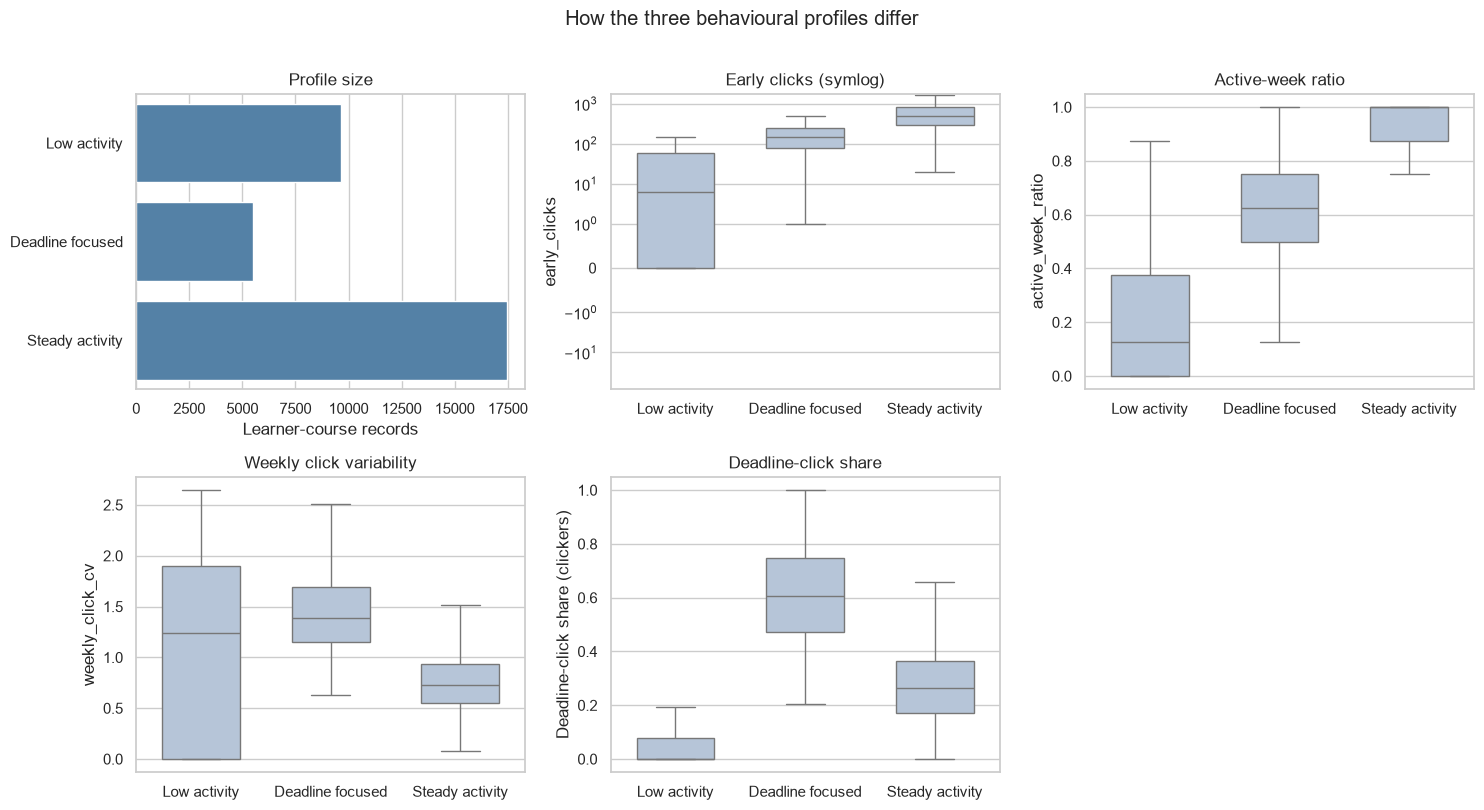

In [798]:
profile_counts = analysis["profile_name"].value_counts().reindex(profile_plot_order)
plot_features = [
    ("early_clicks", "Early clicks (symlog)"),
    ("active_week_ratio", "Active-week ratio"),
    ("weekly_click_cv", "Weekly click variability"),
    ("deadline_click_share", "Deadline-click share"),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sns.barplot(x=profile_counts.values, y=profile_counts.index, color="steelblue", ax=axes[0, 0])
axes[0, 0].set(title="Profile size", xlabel="Learner-course records", ylabel="")
for ax, (feature, title) in zip([axes[0, 1], axes[0, 2], axes[1, 0], axes[1, 1]], plot_features):
    plot_data = analysis.loc[analysis["early_clicks"].gt(0)] if feature == "deadline_click_share" else analysis
    sns.boxplot(data=plot_data, x="profile_name", y=feature, order=profile_plot_order,
                showfliers=False, color="lightsteelblue", ax=ax, width=.6)
    ax.set(title=title, xlabel="", ylabel=feature)
    ax.tick_params(axis="x", rotation=0)
    if feature == "early_clicks":
        ax.set_yscale("symlog", linthresh=1)
axes[1, 2].axis("off")
axes[1, 1].set_ylabel("Deadline-click share (clickers)")
fig.suptitle("How the three behavioural profiles differ", y=1.01)
fig.tight_layout()
save_figure(fig, "04_profile_sizes_and_feature_distributions")
plt.show()

Saved figure: outputs\oulad_figures\01_early_behaviour_by_outcome.pdf


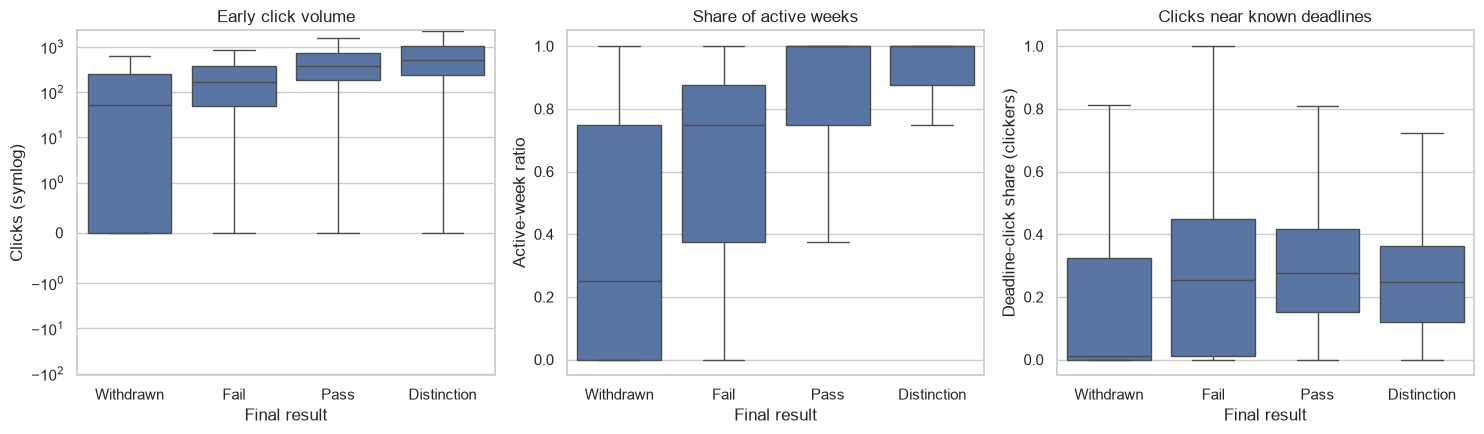

In [799]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=analysis, x="final_result", order=FINAL_RESULT_ORDER, y="early_clicks", showfliers=False, ax=axes[0])
axes[0].set_yscale("symlog", linthresh=1)
axes[0].set(title="Early click volume", xlabel="Final result", ylabel="Clicks (symlog)")
sns.boxplot(data=analysis, x="final_result", order=FINAL_RESULT_ORDER, y="active_week_ratio", showfliers=False, ax=axes[1])
axes[1].set(title="Share of active weeks", xlabel="Final result", ylabel="Active-week ratio")
sns.boxplot(data=analysis, x="final_result", order=FINAL_RESULT_ORDER, y="deadline_click_share", showfliers=False, ax=axes[2])
axes[2].set(title="Clicks near known deadlines", xlabel="Final result", ylabel="Deadline-click share (clickers)")
for ax in axes: ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
save_figure(fig, "01_early_behaviour_by_outcome")
plt.show()

### Outcome differences

The table reports each profile’s withdrawal rate with a 95% Wilson interval. The chi-square test and Cramér’s V summarize the association between profile and all four final-result categories.

In [801]:
def wilson_interval(successes, total, z=1.96):
    if total == 0:
        return (np.nan, np.nan)
    proportion = successes / total
    denominator = 1 + z**2 / total
    center = (proportion + z**2 / (2 * total)) / denominator
    half_width = z * np.sqrt(proportion * (1 - proportion) / total + z**2 / (4 * total**2)) / denominator
    return center - half_width, center + half_width

profile_outcomes = pd.crosstab(analysis["behavior_profile"], analysis["final_result"])
profile_outcomes = profile_outcomes.reindex(index=profile_order, columns=FINAL_RESULT_ORDER, fill_value=0)
chi2_h1, p_h1, dof_h1, expected_h1 = chi2_contingency(profile_outcomes)
cramers_v = np.sqrt(chi2_h1 / (profile_outcomes.to_numpy().sum() * min(profile_outcomes.shape[0] - 1, profile_outcomes.shape[1] - 1)))
p_h1_text = "<0.001" if p_h1 < 0.001 else f"{p_h1:.3f}"
print(f"RQ1 chi-square test of profile vs final outcome: chi-square={chi2_h1:.2f}, df={dof_h1}, p={p_h1_text}; Cramér's V={cramers_v:.3f}.")
print("The p-value tests whether profile and outcome are independent; it is not the probability that RQ1 is true.")

withdrawal_rows = []
for profile in profile_order:
    group = analysis.loc[analysis["behavior_profile"].eq(profile)]
    count = int(group["withdrawn"].sum())
    low, high = wilson_interval(count, len(group))
    withdrawal_rows.append({
        "Profile": profile_labels[profile], "Learner-course records": len(group),
        "Withdrawals": count, "Withdrawal rate": f"{count / len(group):.1%}",
        "95% Wilson interval": f"{low:.1%}–{high:.1%}",
    })
profile_withdrawal = pd.DataFrame(withdrawal_rows)
withdrawal_rates = analysis.groupby("behavior_profile")["withdrawn"].mean()
rq1_supported = bool(p_h1 < 0.05 and withdrawal_rates[low_profile] > withdrawal_rates[steady_profile])
display(profile_withdrawal)

RQ1 chi-square test of profile vs final outcome: chi-square=8123.14, df=6, p=<0.001; Cramér's V=0.353.
The p-value tests whether profile and outcome are independent; it is not the probability that RQ1 is true.


,Profile,Learner-course records,Withdrawals,Withdrawal rate,95% Wilson interval
0,Low activity,9632,5815,60.4%,59.4%–61.3%
1,Deadline focused,5513,1692,30.7%,29.5%–31.9%
2,Steady activity,17448,2649,15.2%,14.7%–15.7%


Saved figure: outputs\oulad_figures\03_profile_outcomes_and_signatures.pdf


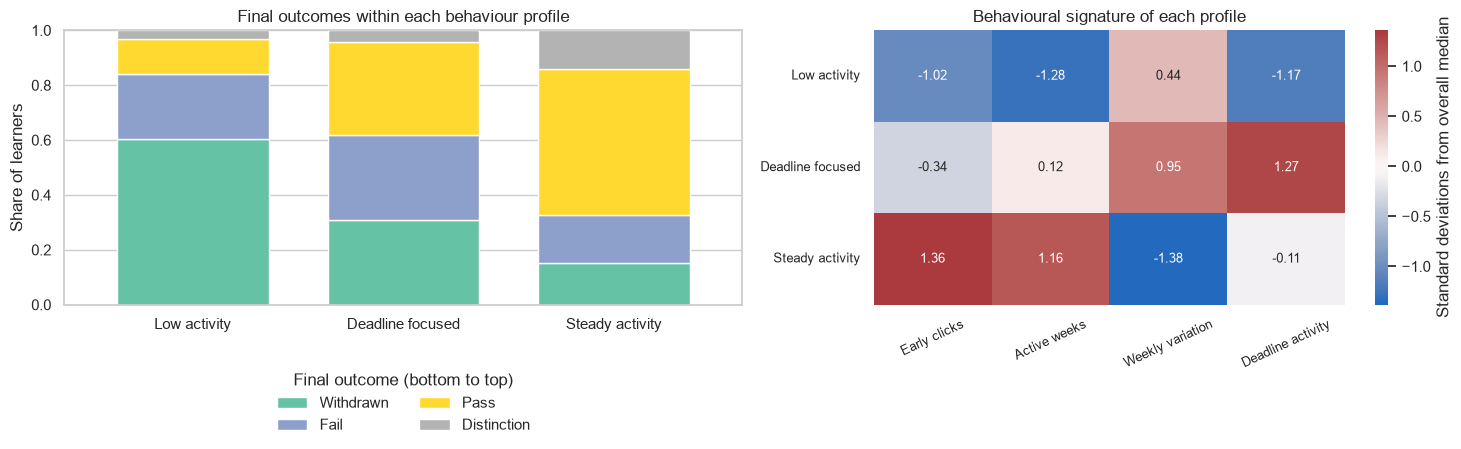

In [802]:
# Left: stacked proportions in requested bottom-to-top order. Right: standardized profile medians.
outcome_share = profile_outcomes.div(profile_outcomes.sum(axis=1), axis=0)
outcome_share.index = [profile_labels[p] for p in profile_order]
heat_features = profile_summary.set_index("behavior_profile").loc[
    profile_order, ["median_early_clicks", "median_active_week_ratio", "median_weekly_cv", "median_deadline_click_share"]
]
heat_features.index = [profile_labels[p] for p in profile_order]
heat_z = (heat_features - heat_features.mean()) / heat_features.std(ddof=0).replace(0, 1)
heat_z.columns = ["Early clicks", "Active weeks", "Weekly variation", "Deadline activity"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1.15, 1]})
outcome_share.plot(kind="bar", stacked=True, width=.72, ax=axes[0], colormap="Set2")
axes[0].set(title="Final outcomes within each behaviour profile", xlabel="", ylabel="Share of learners", ylim=(0, 1))
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Final outcome (bottom to top)", loc="upper center", bbox_to_anchor=(.5, -.2), ncol=2, frameon=False)
sns.heatmap(heat_z, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[1],
            annot_kws={"size": 9}, cbar_kws={"label": "Standard deviations from overall median"})
axes[1].set(title="Behavioural signature of each profile", xlabel="", ylabel="")
axes[1].tick_params(axis="x", labelrotation=25, labelsize=9)
axes[1].tick_params(axis="y", labelrotation=0, labelsize=9)
fig.tight_layout(rect=[0, .10, 1, 1])
save_figure(fig, "03_profile_outcomes_and_signatures")
plt.show()

Saved figure: outputs\oulad_figures\06_weekly_click_contribution_and_rate.pdf


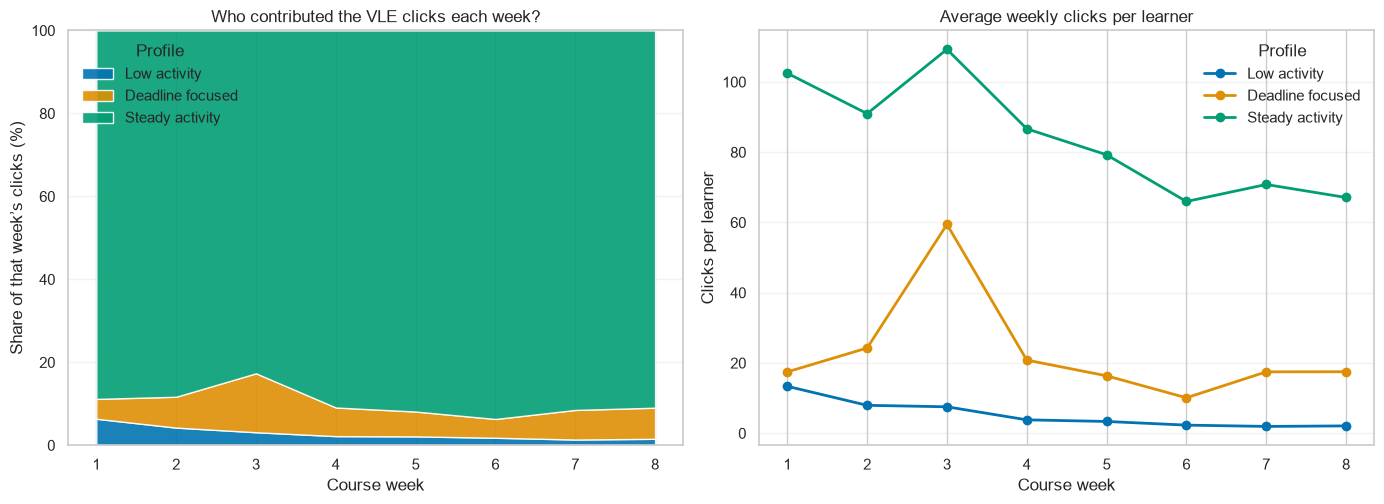

The left panel shows each profile’s contribution to total weekly clicks; the right panel adjusts for different profile sizes. These are descriptive comparisons, not independent evidence used to create the profiles.


In [803]:
# Weekly profile contribution and per-learner click intensity answer different questions.
profile_panel = early_panel.merge(
    analysis[learner_key + ["behavior_profile"]], on=learner_key,
    how="left", validate="many_to_one"
)
weekly_click_totals = profile_panel.groupby(
    ["week", "behavior_profile"])["weekly_clicks"].sum().unstack(fill_value=0)
weekly_click_totals = weekly_click_totals.reindex(columns=profile_order, fill_value=0)
weekly_click_share = weekly_click_totals.div(weekly_click_totals.sum(axis=1), axis=0) * 100
weekly_click_per_learner = profile_panel.groupby(
    ["week", "behavior_profile"])["weekly_clicks"].mean().unstack()
weekly_click_per_learner = weekly_click_per_learner.reindex(columns=profile_order)
weeks = weekly_click_totals.index.to_numpy() + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
colors = [profile_colors[p] for p in profile_order]
axes[0].stackplot(weeks, weekly_click_share.to_numpy().T,
                  labels=[profile_labels[p] for p in profile_order], colors=colors, alpha=.9)
axes[0].set(title="Who contributed the VLE clicks each week?",
            xlabel="Course week", ylabel="Share of that week’s clicks (%)", ylim=(0, 100))
for profile in profile_order:
    axes[1].plot(weeks, weekly_click_per_learner[profile], marker="o", linewidth=2,
                 color=profile_colors[profile], label=profile_labels[profile])
axes[1].set(title="Average weekly clicks per learner",
            xlabel="Course week", ylabel="Clicks per learner")
for ax in axes:
    ax.set_xticks(range(1, EARLY_WEEKS + 1))
    ax.grid(axis="y", alpha=.25)
axes[0].legend(title="Profile", frameon=False, loc="upper left")
axes[1].legend(title="Profile", frameon=False)
fig.tight_layout()
save_figure(fig, "06_weekly_click_contribution_and_rate")
plt.show()
print("The left panel shows each profile’s contribution to total weekly clicks; the right panel adjusts for different profile sizes. These are descriptive comparisons, not independent evidence used to create the profiles.")

### Early assessment features

Summarize scheduled assessments, submissions, timing, and observed scores in the first eight weeks. These features support the profile timeline and the separate early-risk model.

In [805]:
# Assessment definitions with known due dates in the first eight weeks.
assessment_defs = tables["assessments"].loc[
    tables["assessments"]["date"].between(0, EARLY_DAYS - 1),
    ["id_assessment"] + learner_key[:2] + ["date"],
].copy()
assessment_rows = tables["studentAssessment"].merge(
    assessment_defs, on="id_assessment", how="inner", validate="many_to_one"
)
# Keep only submissions available by the week-8 prediction cutoff; banked scores are prior-presentation credit.
assessment_rows = assessment_rows.loc[
    assessment_rows["is_banked"].eq(0) & (assessment_rows["date_submitted"] < EARLY_DAYS)
].copy()
assessment_rows["submission_offset_days"] = assessment_rows["date_submitted"] - assessment_rows["date"]
assessment_rows["was_late"] = assessment_rows["submission_offset_days"] > 0

# All recorded submissions contribute to submission counts and timing, even if their score is blank.
submission_features = assessment_rows.groupby(learner_key, as_index=False).agg(
    early_submission_count=("id_assessment", "nunique"),
    early_mean_submission_offset=("submission_offset_days", "mean"),
    early_late_share=("was_late", "mean"),
)
# Drop missing-score rows only from score-specific summaries; do not discard the submission event.
score_rows = assessment_rows.dropna(subset=["score"]).copy()
score_rows = score_rows.sort_values(["date", "id_assessment"])
score_features = score_rows.groupby(learner_key, as_index=False).agg(
    early_score_mean=("score", "mean"),
    early_score_min=("score", "min"),
    early_score_sd=("score", "std"),
    early_scored_count=("score", "count"),
    _first_observed_score=("score", "first"),
    _last_observed_score=("score", "last"),
)
score_features["early_score_change"] = (
    score_features["_last_observed_score"] - score_features["_first_observed_score"]
)
score_features = score_features.drop(columns=["_first_observed_score", "_last_observed_score"])
submitted_features = submission_features.merge(score_features, on=learner_key, how="left", validate="one_to_one")
scheduled = assessment_defs.groupby(course_key)["id_assessment"].nunique().rename("early_assessments_scheduled").reset_index()
early_assessment_features = student_course[learner_key].merge(
    scheduled, on=course_key, how="left", validate="many_to_one"
).merge(submitted_features, on=learner_key, how="left", validate="one_to_one")
for col in ["early_assessments_scheduled", "early_scored_count", "early_submission_count"]:
    early_assessment_features[col] = early_assessment_features[col].fillna(0)
early_assessment_features["early_unscored_submission_count"] = (
    early_assessment_features["early_submission_count"] - early_assessment_features["early_scored_count"]
).clip(lower=0)
early_assessment_features["early_missing_submission_count"] = (
    early_assessment_features["early_assessments_scheduled"] - early_assessment_features["early_submission_count"]
).clip(lower=0)
early_assessment_features["early_submission_rate"] = np.divide(
    early_assessment_features["early_submission_count"],
    early_assessment_features["early_assessments_scheduled"],
    out=np.full(len(early_assessment_features), np.nan, dtype=float),
    where=early_assessment_features["early_assessments_scheduled"].to_numpy() > 0,
)
analysis = analysis.drop(columns=[c for c in early_assessment_features.columns if c not in learner_key and c in analysis.columns], errors="ignore")
analysis = analysis.merge(early_assessment_features, on=learner_key, how="left", validate="one_to_one")
print(f"Early submission records retained for counts/timing: {len(assessment_rows):,}.")
print(f"Submission rows with observed scores used for score summaries: {len(score_rows):,}; omitted only from score summaries: {len(assessment_rows) - len(score_rows):,}.")
print(f"Learners with at least one observed early score: {analysis['early_score_mean'].notna().sum():,} / {len(analysis):,}.")
print("Unscored submissions and missed assessments remain separate features; score values are never set to zero.")
print("Score change is last minus first observed early score in assessment due-date order; the model also receives the scored count.")
display(analysis[learner_key + ["early_assessments_scheduled", "early_submission_count", "early_submission_rate", "early_unscored_submission_count", "early_score_mean", "early_score_change", "early_late_share"]].head())

Early submission records retained for counts/timing: 42,400.
Submission rows with observed scores used for score summaries: 42,358; omitted only from score summaries: 42.
Learners with at least one observed early score: 23,072 / 32,593.
Unscored submissions and missed assessments remain separate features; score values are never set to zero.
Score change is last minus first observed early score in assessment due-date order; the model also receives the scored count.


,code_module,code_presentation,id_student,early_assessments_scheduled,early_submission_count,early_submission_rate,early_unscored_submission_count,early_score_mean,early_score_change,early_late_share
0,AAA,2013J,11391,2.0,2.0,1.0,0.0,81.5,7.0,0.0
1,AAA,2013J,28400,2.0,2.0,1.0,0.0,69.0,-2.0,0.5
2,AAA,2013J,30268,2.0,0.0,0.0,0.0,NaN,NaN,NaN
3,AAA,2013J,31604,2.0,2.0,1.0,0.0,71.5,-1.0,0.0
4,AAA,2013J,32885,2.0,1.0,0.5,0.0,69.0,0.0,1.0


### Assessment behaviour over time

This chart compares the profiles’ share of weekly early submissions and their late-submission rate by assessment due week.

Saved figure: outputs\oulad_figures\06b_weekly_assessment_behaviour_by_profile.pdf


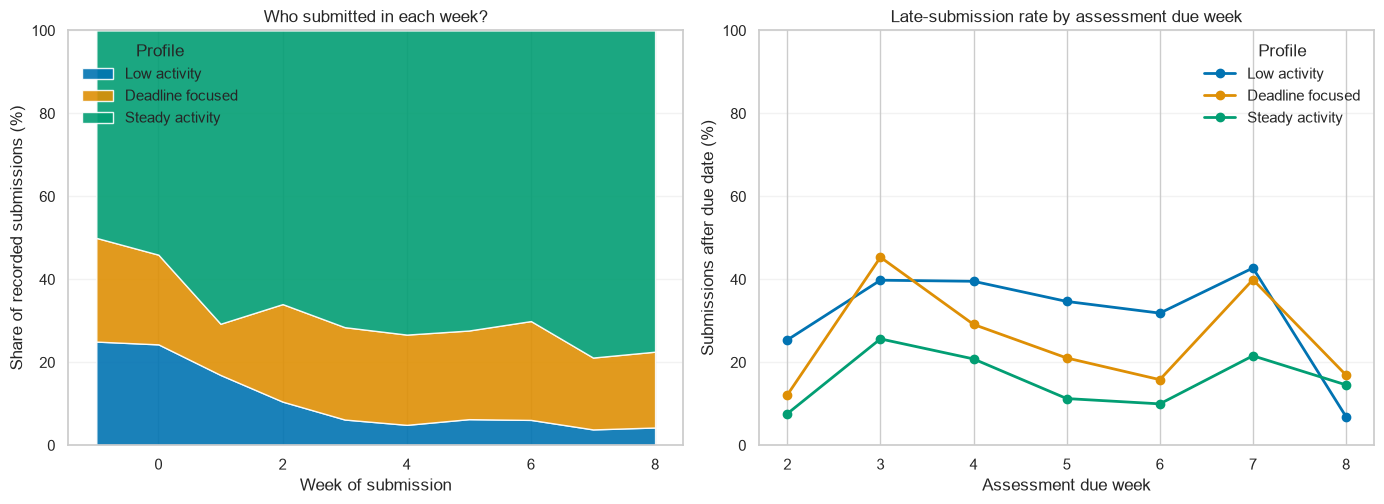

,Recorded early submissions
behavior_profile,
Low activity,2369
Deadline focused,8766
Steady activity,31265


In [807]:
assessment_temporal = assessment_rows.merge(
    analysis[learner_key + ["behavior_profile"]], on=learner_key,
    how="left", validate="many_to_one"
).copy()
assessment_temporal["submission_week"] = (assessment_temporal["date_submitted"] // 7).astype(int) + 1
assessment_temporal["due_week"] = (assessment_temporal["date"] // 7).astype(int) + 1

submission_counts = assessment_temporal.groupby(
    ["submission_week", "behavior_profile"])["id_assessment"].size().unstack(fill_value=0)
submission_counts = submission_counts.reindex(columns=profile_order, fill_value=0)
submission_share = submission_counts.div(submission_counts.sum(axis=1), axis=0) * 100
late_by_due_week = assessment_temporal.groupby(
    ["due_week", "behavior_profile"])["was_late"].mean().unstack()
late_by_due_week = late_by_due_week.reindex(columns=profile_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
submission_weeks = submission_share.index.to_numpy()
axes[0].stackplot(submission_weeks, submission_share.to_numpy().T,
                  labels=[profile_labels[p] for p in profile_order],
                  colors=[profile_colors[p] for p in profile_order], alpha=.9)
axes[0].set(title="Who submitted in each week?", xlabel="Week of submission",
            ylabel="Share of recorded submissions (%)", ylim=(0, 100))
for profile in profile_order:
    axes[1].plot(late_by_due_week.index, late_by_due_week[profile] * 100,
                 marker="o", linewidth=2, color=profile_colors[profile],
                 label=profile_labels[profile])
axes[1].set(title="Late-submission rate by assessment due week",
            xlabel="Assessment due week", ylabel="Submissions after due date (%)", ylim=(0, 100))
for ax in axes:
    ax.grid(axis="y", alpha=.25)
axes[0].legend(title="Profile", frameon=False, loc="upper left")
axes[1].legend(title="Profile", frameon=False)
fig.tight_layout()
save_figure(fig, "06b_weekly_assessment_behaviour_by_profile")
plt.show()
display(submission_counts.rename(columns=profile_labels).sum().rename("Recorded early submissions").to_frame())

## 4. Research question 2 — Early at-risk prediction

**RQ2:** Can data available by the end of week 8 identify learners who eventually Fail or Withdraw?

**H2:** Early engagement, assessment progress, and learner/course context will distinguish at-risk from successful learners better than chance (ROC-AUC > 0.50).

**Target:** Fail/Withdrawn = at risk; Pass/Distinction = not at risk. Predictors use first-eight-week activity and assessments plus course-start context; final outcome and unregistration date are excluded. Missing scores are not treated as zero.

**Evaluation:** Split by learner into 80% training and 20% test sets. At threshold 0.50, report accuracy, balanced accuracy, at-risk precision, recall and F1, Cohen’s kappa, confusion matrix, ROC-AUC, and held-out permutation importance.

## 5. Model and results

A 200-tree Random Forest is fitted to the week-eight predictors using the learner-grouped training split. The next cells report held-out prediction metrics and rank features by their effect on ROC-AUC.

In [810]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve, f1_score,
                             recall_score, precision_score, cohen_kappa_score)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "early_clicks", "active_week_ratio", "weekly_click_cv", "deadline_click_share",
    "early_clicks_first4", "early_clicks_last4", "early_click_trend",
    "longest_inactive_gap_weeks", "early_clicks_per_studied_credit", "registration_lead_days",
    "early_score_mean", "early_score_min", "early_score_sd", "early_score_change", "early_scored_count",
    "early_assessments_scheduled", "early_submission_count", "early_submission_rate",
    "early_unscored_submission_count", "early_missing_submission_count",
    "early_mean_submission_offset", "early_late_share",
    "num_of_prev_attempts", "studied_credits",
]
categorical_features = ["code_module", "code_presentation", "gender", "region",
                        "highest_education", "imd_band", "age_band", "disability"]
predictor_columns = numeric_features + categorical_features
X = analysis[predictor_columns].copy()
y = analysis["fail_or_withdrawn"].astype("int8")  # 1 = Fail/Withdrawn (at risk)
groups = analysis["id_student"]

# Keep every record for a learner on only one side of the split.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]
assert set(groups_train).isdisjoint(set(groups_test)), "Same learner appears in train and test"

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=True))])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent", add_indicator=True)),
                     ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocess = ColumnTransformer([("numeric", num_pipe, numeric_features),
                                ("categorical", cat_pipe, categorical_features)])
rf_pipeline = Pipeline([("preprocess", preprocess), ("model", RandomForestClassifier(
    n_estimators=200, class_weight="balanced_subsample", random_state=SEED, n_jobs=-1))])
best_rf = rf_pipeline.fit(X_train, y_train)

print(f"Train rows={len(X_train):,}; test rows={len(X_test):,}; distinct learners train/test={groups_train.nunique():,}/{groups_test.nunique():,}; overlap=0")
print(f"At-risk rate: train={y_train.mean():.3f}; test={y_test.mean():.3f}")
print("Random Forest fitted once; no cross-validation or hyperparameter search.")

# Imputation is fitted on training data only; no learner rows are dropped.
preprocessor = best_rf.named_steps["preprocess"]
num_imputer = preprocessor.named_transformers_["numeric"].named_steps["imputer"]
cat_imputer = preprocessor.named_transformers_["categorical"].named_steps["imputer"]
def imputation_audit(frame):
    cleaned = frame.copy()
    for column, value in zip(numeric_features, num_imputer.statistics_):
        cleaned[column] = cleaned[column].fillna(value)
    for column, value in zip(categorical_features, cat_imputer.statistics_):
        cleaned[column] = cleaned[column].fillna(value)
    return int(frame.isna().sum().sum()), int(cleaned.isna().sum().sum())
train_before, train_after = imputation_audit(X_train)
test_before, test_after = imputation_audit(X_test)
imputation_report = pd.DataFrame([
    {"Partition": "Training predictors", "Missing cells before": train_before, "Missing cells after": train_after},
    {"Partition": "Test predictors", "Missing cells before": test_before, "Missing cells after": test_after},
])
print("Imputation uses medians/modes learned from training data; learners are retained.")
display(imputation_report)

Train rows=26,122; test rows=6,471; distinct learners train/test=23,028/5,757; overlap=0
At-risk rate: train=0.529; test=0.525
Random Forest fitted once; no cross-validation or hyperparameter search.
Imputation uses medians/modes learned from training data; learners are retained.


,Partition,Missing cells before,Missing cells after
0,Training predictors,53693,0
1,Test predictors,13427,0


Held-out ROC-AUC: 0.8814  |  target >0.80: MET


,Accuracy,Balanced accuracy,At-risk precision,At-risk recall,At-risk F1,Cohen’s kappa,False negatives
0,0.798,0.8,0.843,0.756,0.797,0.597,829


                    precision    recall  f1-score   support

Pass / Distinction       0.76      0.84      0.80      3073
  Fail / Withdrawn       0.84      0.76      0.80      3398

          accuracy                           0.80      6471
         macro avg       0.80      0.80      0.80      6471
      weighted avg       0.80      0.80      0.80      6471

Saved figure: outputs\oulad_figures\07_rf_roc_and_confusion_matrix.pdf


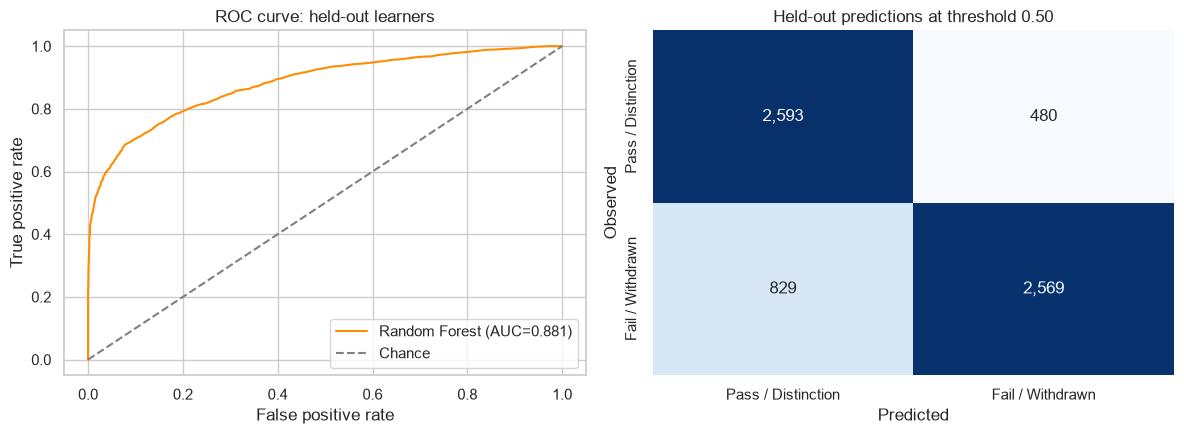

,Feature,Mean ROC-AUC drop,Permutation SD
10,early_score_mean,0.0161,0.0002
17,early_submission_rate,0.0107,0.0002
11,early_score_min,0.0099,0.0006
24,code_module,0.0072,0.0006
5,early_clicks_last4,0.0061,0.0010
20,early_mean_submission_offset,0.0039,0.0007
19,early_missing_submission_count,0.0038,0.0004
7,longest_inactive_gap_weeks,0.0030,0.0006
28,highest_education,0.0028,0.0007
8,early_clicks_per_studied_credit,0.0027,0.0003


Saved figure: outputs\oulad_figures\08_rf_permutation_importance.pdf


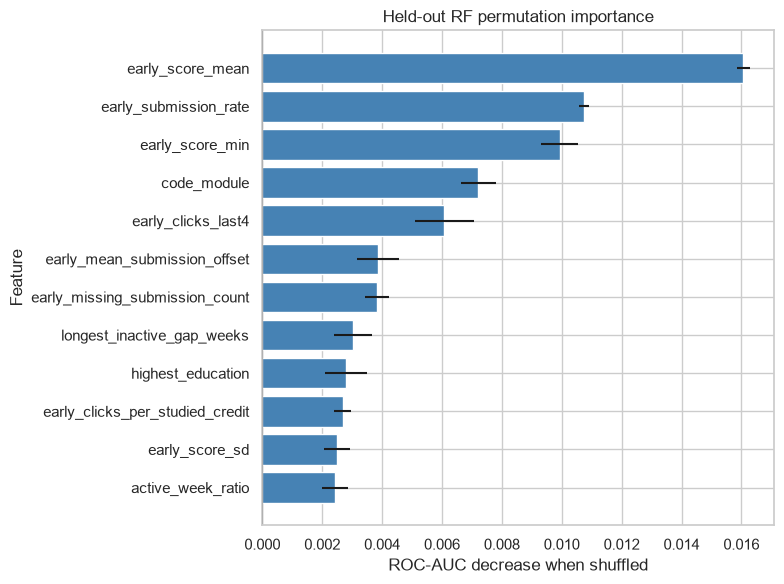

In [811]:
y_probability = best_rf.predict_proba(X_test)[:, 1]
y_prediction = (y_probability >= 0.50).astype("int8")
test_auc = roc_auc_score(y_test, y_probability)
test_accuracy = accuracy_score(y_test, y_prediction)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_prediction)
test_precision = precision_score(y_test, y_prediction, zero_division=0)
test_recall = recall_score(y_test, y_prediction, zero_division=0)
test_f1 = f1_score(y_test, y_prediction, zero_division=0)
test_kappa = cohen_kappa_score(y_test, y_prediction)
false_negatives = int(((y_test == 1) & (y_prediction == 0)).sum())
print(f"Held-out ROC-AUC: {test_auc:.4f}  |  target >0.80: {'MET' if test_auc > 0.80 else 'NOT MET'}")
metrics = pd.DataFrame([{
    "Accuracy": test_accuracy, "Balanced accuracy": test_balanced_accuracy,
    "At-risk precision": test_precision, "At-risk recall": test_recall,
    "At-risk F1": test_f1, "Cohen’s kappa": test_kappa,
    "False negatives": false_negatives,
}])
display(metrics.round(3))
print(classification_report(y_test, y_prediction,
      target_names=["Pass / Distinction", "Fail / Withdrawn"], zero_division=0))
fpr, tpr, _ = roc_curve(y_test, y_probability)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, label=f"Random Forest (AUC={test_auc:.3f})", color="darkorange")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
axes[0].set(title="ROC curve: held-out learners", xlabel="False positive rate", ylabel="True positive rate")
axes[0].legend(loc="lower right")
cm = confusion_matrix(y_test, y_prediction, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[1],
            xticklabels=["Pass / Distinction", "Fail / Withdrawn"],
            yticklabels=["Pass / Distinction", "Fail / Withdrawn"])
axes[1].set(title="Held-out predictions at threshold 0.50", xlabel="Predicted", ylabel="Observed")
plt.tight_layout()
save_figure(fig, "07_rf_roc_and_confusion_matrix")
plt.show()

perm = permutation_importance(best_rf, X_test, y_test, scoring="roc_auc", n_repeats=3,
                              random_state=SEED, n_jobs=-1)
importance = pd.DataFrame({"Feature": predictor_columns,
    "Mean ROC-AUC drop": perm.importances_mean, "Permutation SD": perm.importances_std
}).sort_values("Mean ROC-AUC drop", ascending=False)
display(importance.head(15).round(4))
show = importance.head(12).sort_values("Mean ROC-AUC drop")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(show["Feature"], show["Mean ROC-AUC drop"], xerr=show["Permutation SD"], color="steelblue")
ax.axvline(0, color="black", linewidth=.8)
ax.set(title="Held-out RF permutation importance", xlabel="ROC-AUC decrease when shuffled", ylabel="Feature")
plt.tight_layout()
save_figure(fig, "08_rf_permutation_importance")
plt.show()

### Reading the results

- **RQ1:** The p-value tests whether profile and outcome are associated; it is not the probability that H1 is true. Cramér’s V summarizes association strength.
- **Wilson interval:** The table’s 95% range shows uncertainty around each withdrawal rate.
- **ROC-AUC:** Measures how well the model ranks at-risk learners above successful learners across thresholds.
- **Permutation importance:** Shows how much held-out ROC-AUC changes when a feature is shuffled; it is not causal or variance-explained evidence.

## 6. Conclusions

The next cell summarizes the evidence for H1 and reports the held-out prediction results for H2.

In [814]:
withdrawal_rates = analysis.groupby("behavior_profile")["withdrawn"].mean()
rq1_supported = bool(p_h1 < 0.05 and withdrawal_rates[profile_order[0]] > withdrawal_rates[profile_order[-1]])
rq1_status = "Supported" if rq1_supported else "Not supported by the directional test"
print(f"RQ1 — {rq1_status}: selected K={selected_k}; Cramér's V={cramers_v:.3f}; p={p_h1_text}.")
print(f"Withdrawal rate: Low activity={withdrawal_rates[profile_order[0]]:.1%}; Steady activity={withdrawal_rates[profile_order[-1]]:.1%}.")
print(f"RQ2 — held-out ROC-AUC={test_auc:.3f}; at-risk recall={test_recall:.3f}; precision={test_precision:.3f}; F1={test_f1:.3f}.")
print("Most useful held-out predictors by permutation importance:", ", ".join(importance.head(5).Feature))
results = pd.DataFrame([
    {"Question": "RQ1: behavioural profiles", "Evidence": f"K={selected_k}; Cramér's V={cramers_v:.3f}; withdrawal range={withdrawal_rates.max()-withdrawal_rates.min():.1%}", "p-value": p_h1_text, "Conclusion": rq1_status},
    {"Question": "RQ2: early at-risk prediction", "Evidence": f"Test ROC-AUC={test_auc:.3f}; recall={test_recall:.3f}; precision={test_precision:.3f}; F1={test_f1:.3f}", "p-value": "Not applicable", "Conclusion": "Predictive evaluation"},
])
display(results)
analysis.to_csv(PROCESSED_DIR / "oulad_early_hypothesis_features.csv", index=False)
results.to_csv(PROCESSED_DIR / "oulad_hypothesis_and_model_results.csv", index=False)
k_sweep.to_csv(PROCESSED_DIR / "oulad_kmeans_k_sweep.csv", index=False)
importance.to_csv(PROCESSED_DIR / "oulad_rf_permutation_importance.csv", index=False)
print("Saved analysis tables under:", PROCESSED_DIR)

RQ1 — Supported: selected K=3; Cramér's V=0.353; p=<0.001.
Withdrawal rate: Low activity=60.4%; Steady activity=15.2%.
RQ2 — held-out ROC-AUC=0.881; at-risk recall=0.756; precision=0.843; F1=0.797.
Most useful held-out predictors by permutation importance: early_score_mean, early_submission_rate, early_score_min, code_module, early_clicks_last4


,Question,Evidence,p-value,Conclusion
0,RQ1: behavioural profiles,K=3; Cramér's V=0.353; withdrawal range=45.2%,<0.001,Supported
1,RQ2: early at-risk prediction,Test ROC-AUC=0.881; recall=0.756; precision=0....,Not applicable,Predictive evaluation


Saved analysis tables under: C:\Users\mradu\Documents\Codex\2026-10-02\hi\data\processed


### Limitations

- VLE clicks represent recorded platform activity, not attention or offline study.
- Profile labels depend on the selected features and K; the PCA map is only a two-dimensional display.
- Week-eight prediction may vary across course presentations; one grouped split does not establish future-course performance.
- Demographic predictors need fairness review before intervention. The chi-square test also treats learner-course records as independent, so interpret its p-value cautiously when learners recur.